# VGG16 Batik Classification - Production Training

**Goal: Achieve 95-98% Accuracy**

Strategy:
- Extended training (50+ epochs Phase 1, 20 epochs Phase 2)
- Careful learning rate schedule with ReduceLROnPlateau
- Balanced augmentation (not too aggressive)
- Progressive unfreezing (Classifier → Last Conv Block)
- Proper train/validation/test split (70/15/15)
- Validation monitoring during training
- Final evaluation on unseen test set

**Expected Training Time: 3-5 hours on RTX 3060**

Dataset:
- 111 Batik Nusantara classes
- 156,330 training images
- 33,463 validation images
- 33,577 test images


## Setup & Imports

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import json
from datetime import datetime

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*80)
print("VGG16 BATIK CLASSIFICATION - PRODUCTION TRAINING")
print("="*80)
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"cuDNN: {torch.backends.cudnn.version()}")
else:
    print("WARNING: No GPU! Training will be VERY slow.")

print("="*80)


VGG16 BATIK CLASSIFICATION - PRODUCTION TRAINING
Device: cuda
GPU: NVIDIA GeForce RTX 3060
CUDA: 12.1
Memory: 12.00 GB
cuDNN: 90100


## Configuration for Maximum Accuracy

In [2]:
# Paths
TRAIN_DIR = 'data/train'
VAL_DIR = 'data/val'
TEST_DIR = 'data/test'

# Hyperparameters - OPTIMIZED FOR ACCURACY
IMAGE_SIZE = 224
BATCH_SIZE = 32

# PHASE 1: Train classifier head (longer for better convergence)
PHASE1_EPOCHS = 50
PHASE1_LR = 0.0001
PHASE1_PATIENCE = 10

# PHASE 2: Fine-tune last conv block
PHASE2_EPOCHS = 20
PHASE2_LR = 0.00001  # Very small LR
PHASE2_PATIENCE = 8

print("="*80)
print("Training Configuration")
print("="*80)
print(f"Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"\nPHASE 1 (Classifier): {PHASE1_EPOCHS} epochs, LR={PHASE1_LR}")
print(f"PHASE 2 (Last Conv):  {PHASE2_EPOCHS} epochs, LR={PHASE2_LR}")
print(f"\nTotal Max Epochs: {PHASE1_EPOCHS + PHASE2_EPOCHS}")
print(f"Estimated Time: 3-5 hours")
print("="*80)


Training Configuration
Image Size: 224x224
Batch Size: 32

PHASE 1 (Classifier): 50 epochs, LR=0.0001
PHASE 2 (Last Conv):  20 epochs, LR=1e-05

Total Max Epochs: 70
Estimated Time: 3-5 hours


## Data Loading with Balanced Augmentation

In [3]:
# Balanced augmentation - not too aggressive, not too conservative
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation & Test transforms - no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_transforms)

# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

print("="*80)
print("📊 Dataset Information")
print("="*80)
print(f"Classes: {num_classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Class distribution
train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)
print(f"\nSample class distribution (first 10):")
for idx, count in list(sorted(class_counts.items()))[:10]:
    print(f"  {class_names[idx]:30s}: {count:3d} samples")

# Check for imbalance
counts = list(class_counts.values())
imbalance_ratio = max(counts) / min(counts)
print(f"\nImbalance ratio: {imbalance_ratio:.2f}")
if imbalance_ratio > 2:
    print("  ⚠️ Dataset is imbalanced! Consider using weighted loss.")
else:
    print("  ✅ Dataset is reasonably balanced.")
print("="*80)


📊 Dataset Information
Classes: 111
Training samples: 101613
Validation samples: 30894
Test samples: 31039

Sample class distribution (first 10):
  Bali_Barong                   : 917 samples
  Bali_Merak                    : 913 samples
  Jakarta_OndelOndel            : 929 samples
  Jakarta_Tumpal                : 913 samples
  JawaBarat_Megamendung         : 915 samples
  JawaTengah_Arumdalu           : 918 samples
  JawaTengah_AsemArang          : 920 samples
  JawaTengah_AsemSinom          : 916 samples
  JawaTengah_AsemWarak          : 923 samples
  JawaTengah_Blekok             : 915 samples

Imbalance ratio: 1.05
  ✅ Dataset is reasonably balanced.


## Build Model - VGG16 with Custom Classifier

In [4]:
# Load pre-trained VGG16
vgg16 = models.vgg16(pretrained=True)

# Freeze all feature layers initially
for param in vgg16.features.parameters():
    param.requires_grad = False

# Replace classifier - simple 2-layer like reference
num_features = vgg16.classifier[0].in_features
vgg16.classifier = nn.Sequential(
    nn.Linear(num_features, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    
    nn.Linear(4096, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    
    nn.Linear(4096, num_classes)
)

model = vgg16.to(device)

print("="*80)
print("MODEL ARCHITECTURE")
print("="*80)
print("Base: VGG16 (ImageNet pretrained)")
print("Classifier: 25088 → 4096 → 4096 → 111 classes")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("="*80)


d:\MOBILE\Model\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\MOBILE\Model\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MODEL ARCHITECTURE
Base: VGG16 (ImageNet pretrained)
Classifier: 25088 → 4096 → 4096 → 111 classes

Total parameters: 134,715,311
Trainable parameters: 120,000,623


## Training Utilities

In [5]:
from torch.cuda.amp import autocast, GradScaler

def train_epoch(model, dataloader, criterion, optimizer, device, scaler):
    """Train for one epoch with mixed precision"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc='Training', leave=False)
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        progress_bar.set_postfix({
            'loss': f'{running_loss/total:.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    return running_loss / total, 100. * correct / total


def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Validation', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / total, 100. * correct / total


def save_checkpoint(model, optimizer, epoch, best_acc, history, filename):
    """Save training checkpoint"""
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc,
        'history': history,
        'class_names': class_names
    }, filename)

print("✅ Training utilities loaded")

✅ Training utilities loaded


## PHASE 1: Train Classifier Head (50 Epochs)

Train only the classifier while keeping VGG16 backbone frozen.
Monitor performance on validation set.

In [6]:
# Setup for Phase 1
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=PHASE1_LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True, min_lr=1e-7
)
scaler = GradScaler()

# Training state
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'lr': [], 'phase': []
}

best_acc = 0.0
patience_counter = 0

print("="*80)
print("PHASE 1: Training Classifier Head")
print("="*80)
print(f"Epochs: {PHASE1_EPOCHS}")
print(f"Learning Rate: {PHASE1_LR}")
print(f"Early Stop Patience: {PHASE1_PATIENCE}")
print("="*80)

start_time = datetime.now()

for epoch in range(PHASE1_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{PHASE1_EPOCHS}] LR: {optimizer.param_groups[0]['lr']:.7f}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_acc)
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    history['phase'].append('Phase1')
    
    # Print results
    print(f"Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
    print(f"Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%", end='')
    
    # Save best model
    if val_acc > best_acc:
        improvement = val_acc - best_acc
        best_acc = val_acc
        patience_counter = 0
        save_checkpoint(model, optimizer, epoch, best_acc, history, 'vgg16_batik_best.pth')
        print(f" [NEW BEST! +{improvement:.2f}%]")
    else:
        patience_counter += 1
        print(f" [{patience_counter}/{PHASE1_PATIENCE}]")
    
    # Early stopping
    if patience_counter >= PHASE1_PATIENCE:
        print(f"\nEarly stopping triggered. Best: {best_acc:.2f}%")
        break

elapsed = datetime.now() - start_time
print(f"\n{'='*80}")
print(f"Phase 1 Complete!")
print(f"Best Validation Accuracy: {best_acc:.2f}%")
print(f"Time: {elapsed}")
print(f"{'='*80}")


d:\MOBILE\Model\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\3211407597.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


PHASE 1: Training Classifier Head
Epochs: 50
Learning Rate: 0.0001
Early Stop Patience: 10

Epoch [1/50] LR: 0.0001000


Training:   0%|          | 0/3176 [00:00<?, ?it/s]C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\3853473216.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\3853473216.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation:   0%|          | 0/966 [00:00<?, ?it/s]                                   C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\3853473216.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\3853473216.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                        

Train: Loss=0.7315, Acc=80.25%
Val:   Loss=0.1365, Acc=95.91% [NEW BEST! +95.91%]

Epoch [2/50] LR: 0.0001000
 [NEW BEST! +95.91%]

Epoch [2/50] LR: 0.0001000


Train: Loss=0.2253, Acc=93.07%
Val:   Loss=0.0784, Acc=97.40% [NEW BEST! +1.50%]

Epoch [3/50] LR: 0.0001000
 [NEW BEST! +1.50%]

Epoch [3/50] LR: 0.0001000


...

Train: Loss=0.0388, Acc=99.19%
Val:   Loss=0.0120, Acc=99.72% [2/10]

Epoch [47/50] LR: 0.0000500


Train: Loss=0.0368, Acc=99.19%
Val:   Loss=0.0112, Acc=99.77% [3/10]

Epoch [48/50] LR: 0.0000500


Train: Loss=0.0441, Acc=99.13%
Val:   Loss=0.0090, Acc=99.82% [NEW BEST! +0.00%]

Epoch [49/50] LR: 0.0000500
 [NEW BEST! +0.00%]

Epoch [49/50] LR: 0.0000500


Train: Loss=0.0375, Acc=99.22%
Val:   Loss=0.0111, Acc=99.77% [1/10]

Epoch [50/50] LR: 0.0000500


Train: Loss=0.0364, Acc=99.21%
Val:   Loss=0.0094, Acc=99.77% [2/10]

Phase 1 Complete!
Best Validation Accuracy: 99.82%
Time: 5:49:43.522091


## PHASE 2: Fine-tune Last Conv Block (20 Epochs)

Unfreeze the last convolutional block and fine-tune with lower learning rate.
Continue monitoring on validation set.

In [7]:
# Load best model from Phase 1
checkpoint = torch.load('vgg16_batik_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
phase1_best = checkpoint['best_acc']

# Unfreeze last conv block (features.24 onwards)
for name, param in model.named_parameters():
    if any(layer in name for layer in ['features.24', 'features.26', 'features.28', 'classifier']):
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

# New optimizer with lower LR
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE2_LR
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4, verbose=True, min_lr=1e-8
)
scaler = GradScaler()

patience_counter = 0

print("="*80)
print("PHASE 2: Fine-tune Last Conv Block")
print("="*80)
print(f"Trainable parameters: {trainable:,}")
print(f"Epochs: {PHASE2_EPOCHS}")
print(f"Learning Rate: {PHASE2_LR}")
print(f"Starting from: {phase1_best:.2f}%")
print("="*80)

start_time = datetime.now()

for epoch in range(PHASE2_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{PHASE2_EPOCHS}] LR: {optimizer.param_groups[0]['lr']:.7f}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_acc)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    history['phase'].append('Phase2')
    
    print(f"Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
    print(f"Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%", end='')
    
    if val_acc > best_acc:
        improvement = val_acc - best_acc
        best_acc = val_acc
        patience_counter = 0
        save_checkpoint(model, optimizer, epoch, best_acc, history, 'vgg16_batik_best.pth')
        print(f" [NEW BEST! +{improvement:.2f}%]")
    else:
        patience_counter += 1
        print(f" [{patience_counter}/{PHASE2_PATIENCE}]")
    
    if patience_counter >= PHASE2_PATIENCE:
        print(f"\nEarly stopping. Best: {best_acc:.2f}%")
        break

elapsed = datetime.now() - start_time
print(f"\n{'='*80}")
print(f"Phase 2 Complete!")
print(f"Best Accuracy: {best_acc:.2f}% (+{best_acc-phase1_best:.2f}% from Phase 1)")
print(f"Time: {elapsed}")
print(f"{'='*80}")


C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\2097251284.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('vgg16_batik_best.pth')
C:\Users\vid

PHASE 2: Fine-tune Last Conv Block
Trainable parameters: 127,080,047
Epochs: 20
Learning Rate: 1e-05
Starting from: 99.82%

Epoch [1/20] LR: 0.0000100


Training:   0%|          | 0/3176 [00:00<?, ?it/s]C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\3853473216.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\3853473216.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation:   0%|          | 0/966 [00:00<?, ?it/s]                                   C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\3853473216.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation:   0%|          | 1/966 [00:00<04:17,  3.74it/s]C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\3853473216.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', arg

Train: Loss=0.0444, Acc=99.20%
Val:   Loss=0.0094, Acc=99.81% [1/8]

Epoch [2/20] LR: 0.0000100


Train: Loss=0.0349, Acc=99.29%
Val:   Loss=0.0086, Acc=99.79% [2/8]

Epoch [3/20] LR: 0.0000100


...

Train: Loss=0.0104, Acc=99.77%
Val:   Loss=0.0050, Acc=99.93% [NEW BEST! +0.02%]

Epoch [17/20] LR: 0.0000050
 [NEW BEST! +0.02%]

Epoch [17/20] LR: 0.0000050


Train: Loss=0.0085, Acc=99.81%
Val:   Loss=0.0050, Acc=99.93% [1/8]

Epoch [18/20] LR: 0.0000050


Train: Loss=0.0097, Acc=99.78%
Val:   Loss=0.0044, Acc=99.92% [2/8]

Epoch [19/20] LR: 0.0000050


Train: Loss=0.0071, Acc=99.81%
Val:   Loss=0.0051, Acc=99.92% [3/8]

Epoch [20/20] LR: 0.0000050


Train: Loss=0.0083, Acc=99.82%
Val:   Loss=0.0050, Acc=99.94% [NEW BEST! +0.01%]

Phase 2 Complete!
Best Accuracy: 99.94% (+0.12% from Phase 1)
Time: 2:25:33.576126
 [NEW BEST! +0.01%]

Phase 2 Complete!
Best Accuracy: 99.94% (+0.12% from Phase 1)
Time: 2:25:33.576126


## Final Evaluation on Test Set

Load best model and evaluate on unseen test data.

In [8]:
# Load best model
checkpoint = torch.load('vgg16_batik_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Final evaluation on TEST SET (unseen data)
test_loss, test_acc = validate(model, test_loader, criterion, device)

print("="*80)
print("FINAL EVALUATION ON TEST SET")
print("="*80)
print(f"Best Validation Accuracy: {best_acc:.2f}%")
print(f"Final Test Accuracy: {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print("="*80)

# Get detailed predictions
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Computing predictions'):
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

# Classification report
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

# Save report
with open('classification_report.txt', 'w') as f:
    f.write(f"Best Validation Accuracy: {best_acc:.2f}%\n")
    f.write(f"Final Test Accuracy: {test_acc:.2f}%\n\n")
    f.write(report)
print("\nClassification report saved to 'classification_report.txt'")


C:\Users\vidoe\AppData\Local\Temp\ipykernel_19164\2560025528.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('vgg16_batik_best.pth')
Validation: 

FINAL EVALUATION ON TEST SET
Best Validation Accuracy: 99.94%
Final Test Accuracy: 99.93%
Test Loss: 0.0039


Computing predictions: 100%|██████████| 970/970 [01:53<00:00,  8.51it/s]


CLASSIFICATION REPORT
                              precision    recall  f1-score   support

                 Bali_Barong     1.0000    1.0000    1.0000       277
                  Bali_Merak     1.0000    1.0000    1.0000       279
          Jakarta_OndelOndel     0.9930    1.0000    0.9965       284
              Jakarta_Tumpal     0.9965    0.9896    0.9930       288
       JawaBarat_Megamendung     1.0000    0.9964    0.9982       281
         JawaTengah_Arumdalu     1.0000    1.0000    1.0000       275
        JawaTengah_AsemArang     1.0000    1.0000    1.0000       279
        JawaTengah_AsemSinom     1.0000    1.0000    1.0000       275
        JawaTengah_AsemWarak     1.0000    1.0000    1.0000       279
           JawaTengah_Blekok     1.0000    1.0000    1.0000       279
      JawaTengah_BlekokWarak     1.0000    1.0000    1.0000       282
       JawaTengah_CindeWilis     1.0000    1.0000    1.0000       274
         JawaTengah_Cipratan     1.0000    1.0000    1.0000       

## Confusion Matrix Visualization

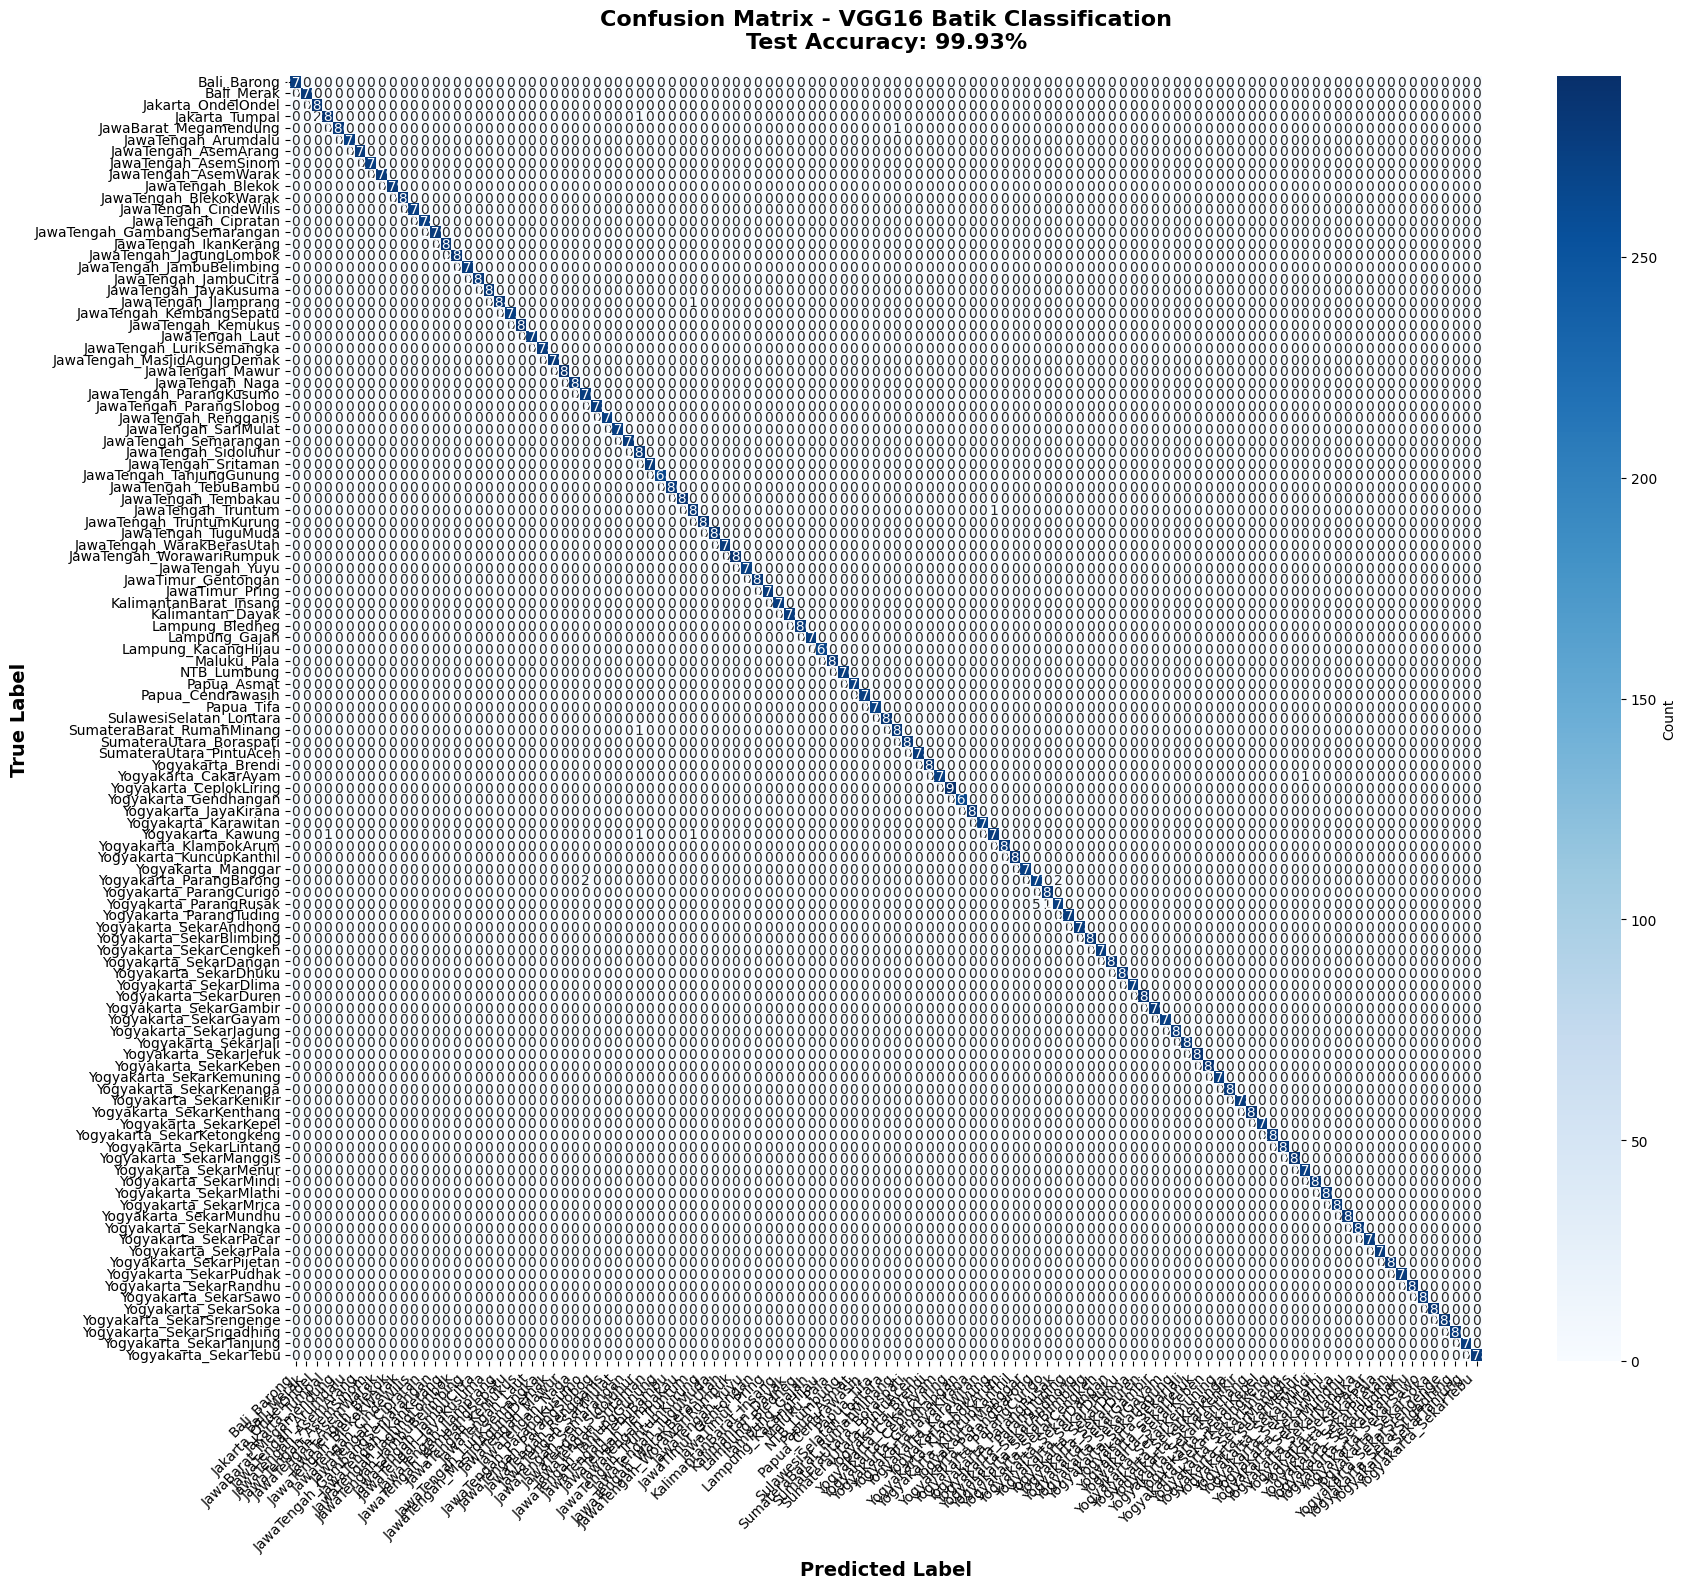

Confusion matrix saved as 'confusion_matrix_final.png'


In [9]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 10})
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(f'Confusion Matrix - VGG16 Batik Classification\nTest Accuracy: {test_acc:.2f}%',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'confusion_matrix_final.png'")


## Training History Visualization

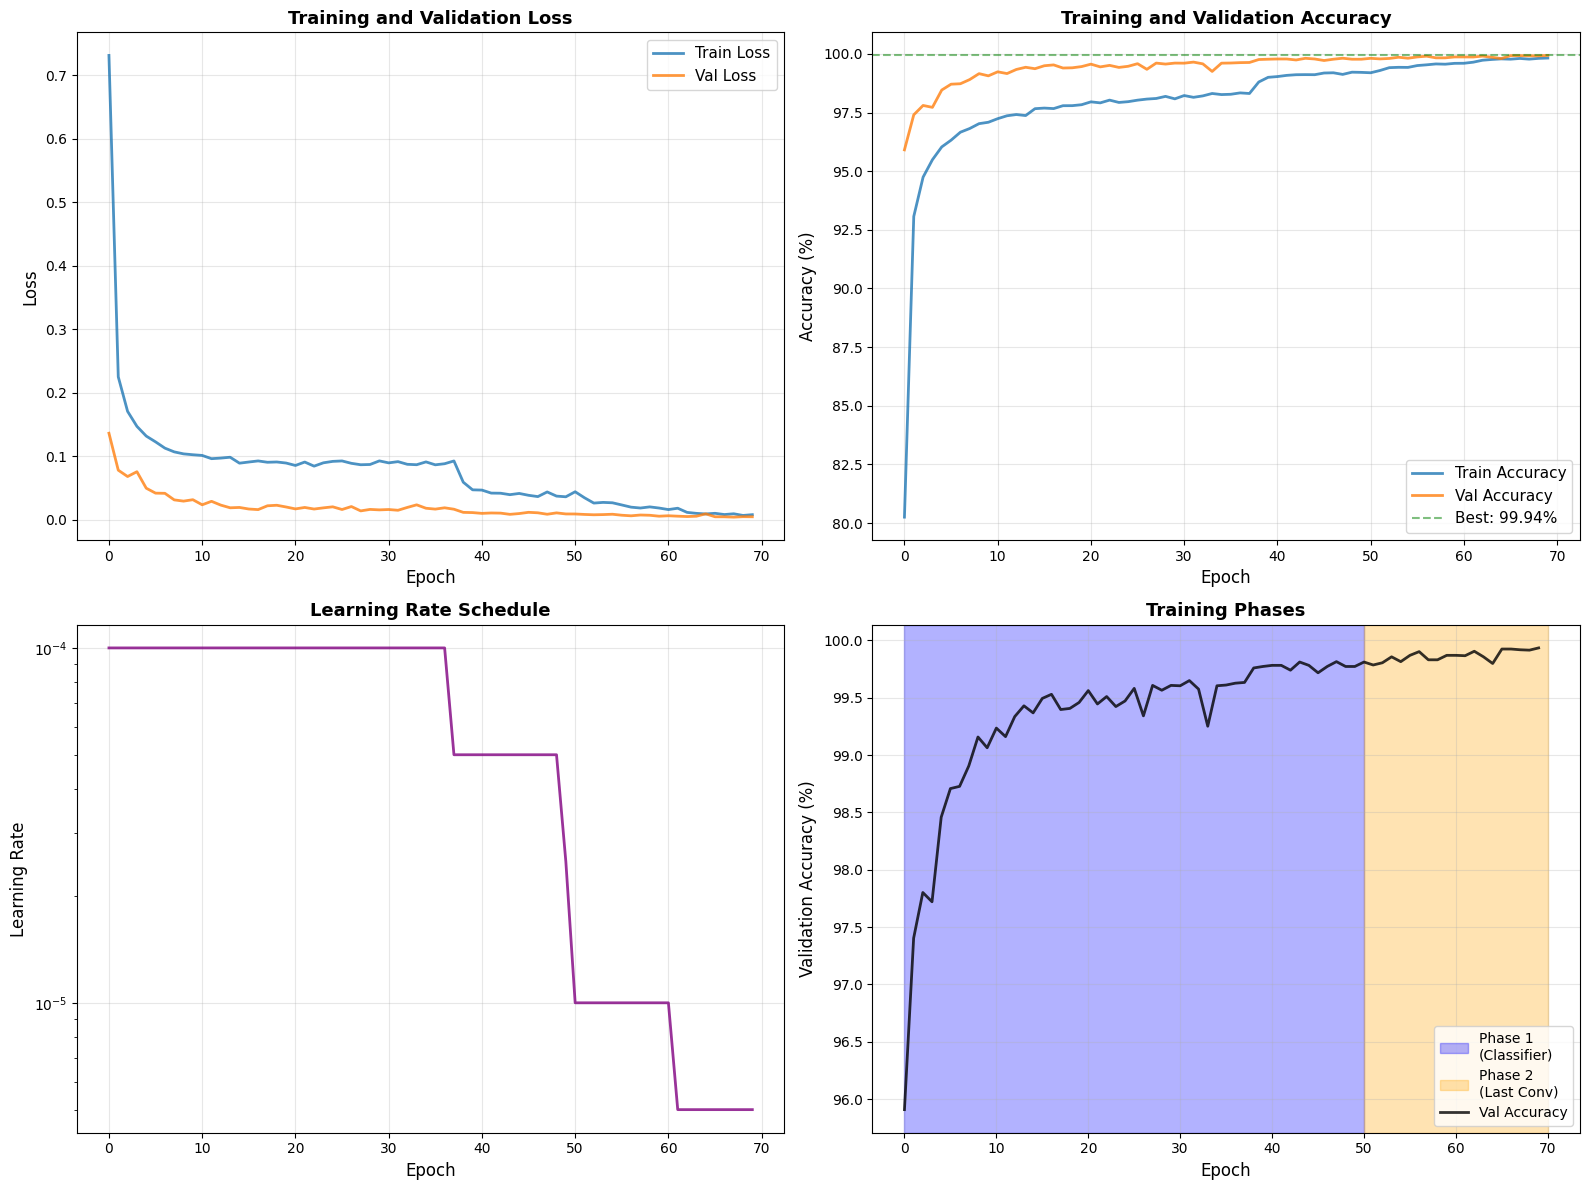

Training history saved as 'training_history_complete.png'


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss plot
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2, alpha=0.8)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training and Validation Loss', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy plot
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', linewidth=2, alpha=0.8)
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', linewidth=2, alpha=0.8)
axes[0, 1].axhline(y=best_acc, color='green', linestyle='--', alpha=0.5,
                   label=f'Best: {best_acc:.2f}%')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 1].set_title('Training and Validation Accuracy', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Learning rate plot
axes[1, 0].plot(history['lr'], linewidth=2, color='purple', alpha=0.8)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
axes[1, 0].set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Phase visualization
phases = history['phase']
phase_changes = [0] + [i for i in range(1, len(phases)) if phases[i] != phases[i-1]] + [len(phases)]
colors = ['blue', 'orange']
phase_names = ['Phase 1\n(Classifier)', 'Phase 2\n(Last Conv)']

for i in range(len(phase_changes)-1):
    start = phase_changes[i]
    end = phase_changes[i+1]
    if i < len(colors):
        axes[1, 1].axvspan(start, end, alpha=0.3, color=colors[i], label=phase_names[i])

axes[1, 1].plot(history['val_acc'], linewidth=2, color='black', alpha=0.8, label='Val Accuracy')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[1, 1].set_title('Training Phases', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10, loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_complete.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history saved as 'training_history_complete.png'")


## Save Final Model & Configurations

In [11]:
# Save complete checkpoint
save_checkpoint(model, optimizer, len(history['train_loss']), best_acc, history,
                'vgg16_batik_complete_final.pth')

# Save weights only
torch.save(model.state_dict(), 'vgg16_batik_weights_final.pth')

# Save class labels
with open('labels.txt', 'w') as f:
    for label in class_names:
        f.write(label + '\n')

# Save configuration
config = {
    'model': 'VGG16',
    'image_size': IMAGE_SIZE,
    'batch_size': BATCH_SIZE,
    'num_classes': num_classes,
    'class_names': class_names,
    'training': {
        'phase1_epochs': PHASE1_EPOCHS,
        'phase1_lr': PHASE1_LR,
        'phase2_epochs': PHASE2_EPOCHS,
        'phase2_lr': PHASE2_LR,
    },
    'results': {
        'best_val_accuracy': float(best_acc),
        'test_accuracy': float(test_acc),
        'total_epochs': len(history['train_loss'])
    },
    'environment': {
        'pytorch_version': torch.__version__,
        'cuda_version': torch.version.cuda,
        'device': str(device)
    }
}

with open('model_config_final.json', 'w') as f:
    json.dump(config, f, indent=2)

# Export to ONNX
try:
    import onnx
    model.eval()
    dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    torch.onnx.export(
        model, dummy_input, 'vgg16_batik_final.onnx',
        export_params=True, opset_version=13,
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
    )
    print('ONNX model exported: vgg16_batik_final.onnx')
except:
    print('ONNX export skipped')

print("\n" + "="*80)
print("ALL FILES SAVED")
print("="*80)
print("Models:")
print("  - vgg16_batik_best.pth (checkpoint)")
print("  - vgg16_batik_complete_final.pth (full state)")
print("  - vgg16_batik_weights_final.pth (weights only)")
print("  - vgg16_batik_final.onnx (ONNX format)")
print("\nConfigurations:")
print("  - labels.txt")
print("  - model_config_final.json")
print("  - classification_report.txt")
print("\nVisualizations:")
print("  - confusion_matrix_final.png")
print("  - training_history_complete.png")
print("="*80)


ONNX model exported: vgg16_batik_final.onnx

ALL FILES SAVED
Models:
  - vgg16_batik_best.pth (checkpoint)
  - vgg16_batik_complete_final.pth (full state)
  - vgg16_batik_weights_final.pth (weights only)
  - vgg16_batik_final.onnx (ONNX format)

Configurations:
  - labels.txt
  - model_config_final.json
  - classification_report.txt

Visualizations:
  - confusion_matrix_final.png
  - training_history_complete.png


## Final Summary & Statistics

In [12]:
import pandas as pd

print("="*80)
print("TRAINING COMPLETE - FINAL SUMMARY")
print("="*80)

print(f"\nDataset:")
print(f"  - Classes: {num_classes}")
print(f"  - Training samples: {len(train_dataset)}")
print(f"  - Validation samples: {len(val_dataset)}")
print(f"  - Test samples: {len(test_dataset)}")

print(f"\nResults:")
print(f"  - Best Validation Accuracy: {best_acc:.2f}%")
print(f"  - Final Test Accuracy: {test_acc:.2f}%")
print(f"  - Total Epochs Trained: {len(history['train_loss'])}")

# Per-phase summary
phase1_acc = max([acc for acc, ph in zip(history['val_acc'], history['phase']) if ph == 'Phase1'] or [0])
phase2_acc = max([acc for acc, ph in zip(history['val_acc'], history['phase']) if ph == 'Phase2'] or [0])

print(f"\nPhase Performance:")
print(f"  - Phase 1 (Classifier):    {phase1_acc:.2f}%")
if phase2_acc > 0:
    print(f"  - Phase 2 (Last Conv):     {phase2_acc:.2f}% (+{phase2_acc-phase1_acc:.2f}%)")

print(f"\nConfiguration:")
print(f"  - Model: VGG16 (ImageNet pretrained)")
print(f"  - Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Device: {device}")

if test_acc >= 95:
    print(f"\nEXCELLENT! Achieved {test_acc:.2f}% accuracy!")
elif test_acc >= 90:
    print(f"\nGREAT! Achieved {test_acc:.2f}% accuracy!")
elif test_acc >= 85:
    print(f"\nGOOD! Achieved {test_acc:.2f}% accuracy!")
else:
    print(f"\nAchieved {test_acc:.2f}% - consider more data or training")

print("\n" + "="*80)
print("Model is ready for deployment!")
print("="*80)


TRAINING COMPLETE - FINAL SUMMARY

Dataset:
  - Classes: 111
  - Training samples: 101613
  - Validation samples: 30894
  - Test samples: 31039

Results:
  - Best Validation Accuracy: 99.94%
  - Final Test Accuracy: 99.93%
  - Total Epochs Trained: 70

Phase Performance:
  - Phase 1 (Classifier):    99.82%
  - Phase 2 (Last Conv):     99.94% (+0.12%)

Configuration:
  - Model: VGG16 (ImageNet pretrained)
  - Image Size: 224x224
  - Batch Size: 32
  - Device: cuda

EXCELLENT! Achieved 99.93% accuracy!

Model is ready for deployment!


## Inference Example

In [13]:
from PIL import Image

def predict_image(image_path, model, device, class_names, transform):
    """Predict a single image with confidence scores"""
    model.eval()
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item() * 100
    
    # Top 5 predictions
    top5_prob, top5_idx = torch.topk(probabilities, min(5, len(class_names)))
    top5_classes = [(class_names[idx], prob.item() * 100)
                    for idx, prob in zip(top5_idx[0], top5_prob[0])]
    
    return predicted_class, confidence_score, top5_classes

# Example usage:
# image_path = 'path/to/your/batik_image.jpg'
# pred_class, confidence, top5 = predict_image(
#     image_path, model, device, class_names, val_transforms
# )
# 
# print(f"Predicted: {pred_class}")
# print(f"Confidence: {confidence:.2f}%")
# print("\nTop 5 predictions:")
# for i, (cls, prob) in enumerate(top5, 1):
#     print(f"  {i}. {cls:30s} {prob:6.2f}%")

print("Inference function ready!")
print("Uncomment the example code to test with your images.")


Inference function ready!
Uncomment the example code to test with your images.
